In [1]:
#  1 — Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#2 — Load your dataset
data = pd.read_csv("Crop_recommendation.csv")

data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
#3 — Check dataset
data.info()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [4]:
#4 — Features & Target
X = data.drop("label", axis=1)
y = data["label"]

In [5]:
#5 — Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:

print("🌾 Crop Recommendation Dataset Ready!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("✅ Model training can start now...")

🌾 Crop Recommendation Dataset Ready!
Training samples: 1760
Testing samples: 440
✅ Model training can start now...


In [7]:
#6 — Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
#7 — Prediction
y_pred = model.predict(X_test)

In [9]:
#8 — Accuracy check
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9931818181818182


C:\Users\PMLS\AppData\Local\Temp\ipykernel_66664\2809009827.py:27: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PMLS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


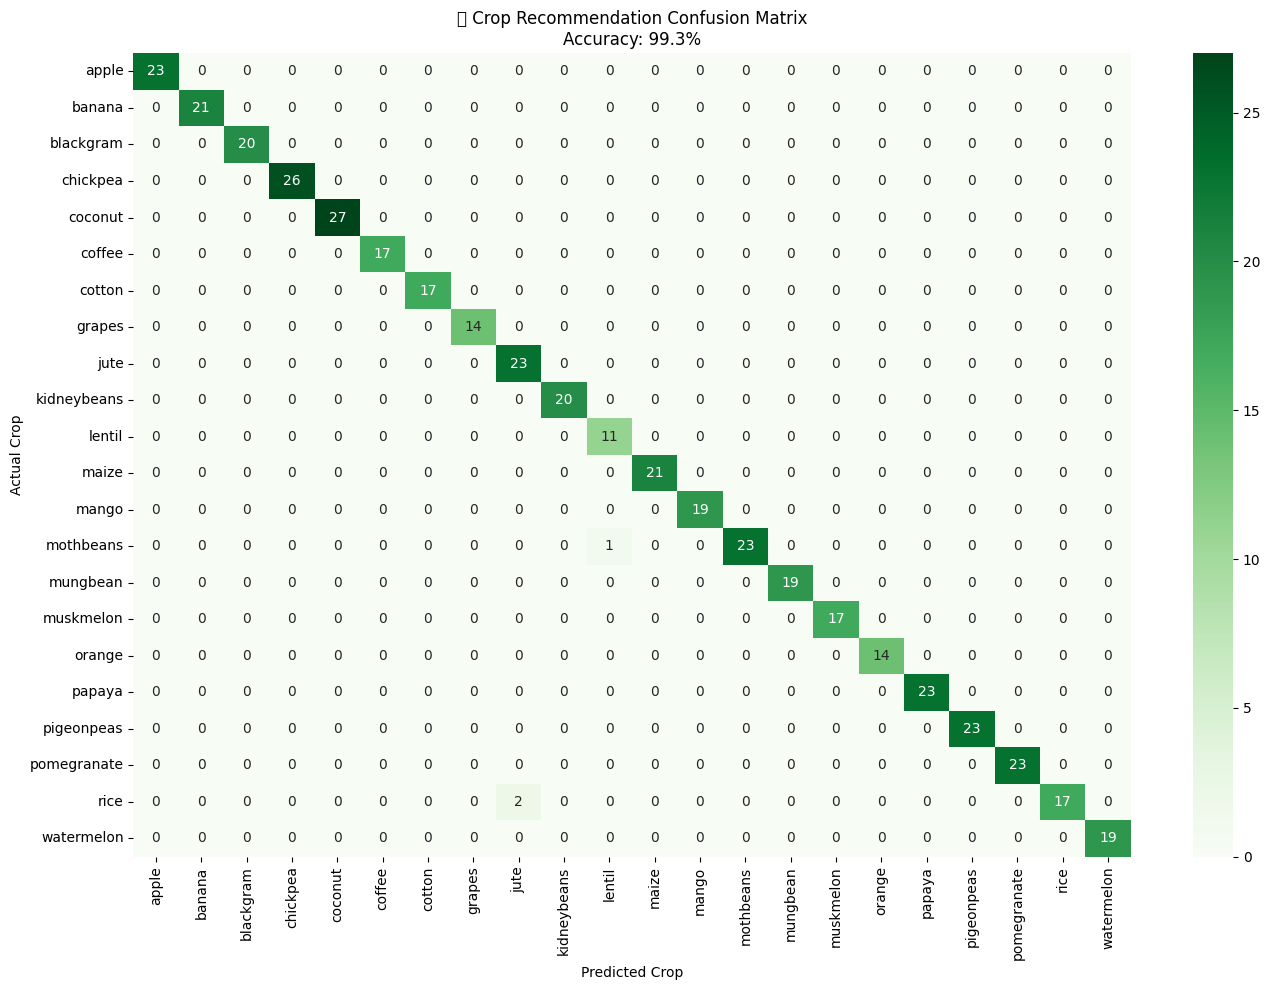

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)

acc = accuracy_score(y_test, y_pred)

plt.title(f'🌾 Crop Recommendation Confusion Matrix\nAccuracy: {acc*100:.1f}%')
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()